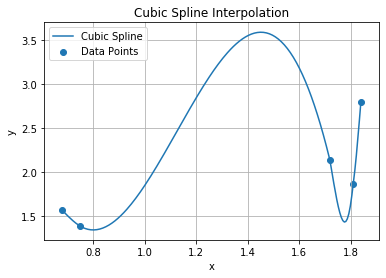

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def spline_coeffs(x, y):
    n = len(x)
    h = np.diff(x)

    A = np.zeros(n)
    B = np.zeros(n)
    C = np.zeros(n)
    D = np.zeros(n)

    B[0] = 1
    B[-1] = 1
    D[0] = 0
    D[-1] = 0

    for i in range(1, n - 1):
        A[i] = h[i - 1] / 6
        B[i] = (h[i - 1] + h[i]) / 3
        C[i] = h[i] / 6
        D[i] = (y[i + 1] - y[i]) / h[i] - (y[i] - y[i - 1]) / h[i - 1]

    #Thomas Algorithm
    for i in range(1, n):
        w = A[i - 1] / B[i - 1]
        B[i] = B[i] - w * C[i - 1]
        D[i] = D[i] - w * D[i - 1]

    #Back substitution
    M = np.zeros(n)
    M[-1] = D[-1] / B[-1]

    for i in range(n - 2, -1, -1):
        M[i] = (D[i] - C[i] * M[i + 1]) / B[i]

    return M


def evaluate_spline(x, y, M, x_eval):
    n = len(x)
    y_eval = []

    for xe in x_eval:
        for i in range(n - 1):
            if x[i] <= xe <= x[i + 1]:
                h = x[i + 1] - x[i]

                t1 = M[i] * (x[i + 1] - xe)**3 / (6 * h)
                t2 = M[i + 1] * (xe - x[i])**3 / (6 * h)
                t3 = (y[i] / h - M[i] * h / 6) * (x[i + 1] - xe)
                t4 = (y[i + 1] / h - M[i + 1] * h / 6) * (xe - x[i])

                y_eval.append(t1+t2+t3+t4)

    return np.array(y_eval)


x = np.array([0.75, 0.68, 1.81, 1.72, 1.84])
y = np.array([1.38, 1.56, 1.86, 2.13, 2.79])

sorted_indices = np.argsort(x)
x = x[sorted_indices]
y = y[sorted_indices]

M = spline_coeffs(x, y)

x_d = np.linspace(min(x), max(x), 200)
y_d = evaluate_spline(x, y, M, x_d)

plt.figure()
plt.plot(x_d, y_d, label="Cubic Spline")
plt.scatter(x, y, label="Data Points")
plt.legend()
plt.title("Cubic Spline Interpolation")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.show()